# Ch05 - 时序差分：SARSA 与 Q-Learning

结合 DP 单步更新与 MC 无模型特性，对比 on-policy 与 off-policy。

> 本 Notebook 配套《强化学习全面教程》PDF 使用。

In [1]:
import numpy as np
import torch
import torch.nn as nn
import gymnasium as gym
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import random
from collections import deque, defaultdict

# 中文字体配置
import os, platform
if platform.system() == 'Linux' and os.path.exists('/usr/share/fonts/truetype/chinese/NotoSansSC-Regular.ttf'):
    fm.fontManager.addfont('/usr/share/fonts/truetype/chinese/NotoSansSC-Regular.ttf')
plt.rcParams['font.sans-serif'] = ['Noto Sans SC', 'DejaVu Sans', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch: {torch.__version__} | 设备: {device} | Gymnasium: {gym.__version__}')


PyTorch: 2.13.0+cpu | 设备: cpu | Gymnasium: 1.3.0


## 5.1 TD(0) 预测

时序差分（TD）学习的核心更新：
$$V(s_t) \leftarrow V(s_t) + \alpha [r_{t+1} + \gamma V(s_{t+1}) - V(s_t)]$$

方括号内是 **TD 误差** $\delta_t = r_{t+1} + \gamma V(s_{t+1}) - V(s_t)$。

TD 用'实际奖励 + 下一状态估值'作为更新目标，比 MC 的完整回报方差小，但有偏差（自举 bootstrap）。

## 5.2 SARSA：on-policy TD 控制

SARSA 名字来源于更新元组 $(S, A, R, S', A')$。用当前策略采样的 $a'$ 更新：
$$Q(s,a) \leftarrow Q(s,a) + \alpha [r + \gamma Q(s', a') - Q(s,a)]$$

SARSA 学到的是'考虑探索的策略价值'——在悬崖边会保守。

## 5.3 Q-Learning：off-policy TD 控制

Q-Learning 直接学最优 $Q^*$，与采样策略无关：
$$Q(s,a) \leftarrow Q(s,a) + \alpha [r + \gamma \max_{a'} Q(s', a') - Q(s,a)]$$

更新目标用 $\max_{a'} Q(s',a')$ 而非实际采样的 $a'$。Q-Learning 假设'未来不会再探索'，学到贴边走最优路径。

## 5.4 CliffWalking：经典对比实验

4×12 网格，左下是起点，右下是目标，最下面一行是悬崖（掉下去 -100 并回到起点）。

- **SARSA** 学到保守路径（绕开悬崖）
- **Q-Learning** 学到最优但危险的路径（贴边走）

In [2]:
env = gym.make('CliffWalking-v1')
print(f'状态数={env.observation_space.n}, 动作数={env.action_space.n}')

def epsilon_greedy(Q, state, nA, epsilon):
    if np.random.random() < epsilon:
        return np.random.randint(nA)
    return int(Q[state].argmax())

def sarsa(env, episodes=500, alpha=0.5, gamma=0.99, epsilon=0.1):
    nS, nA = env.observation_space.n, env.action_space.n
    Q = np.zeros((nS, nA))
    rewards = []
    for ep in range(episodes):
        s, _ = env.reset()
        a = epsilon_greedy(Q, s, nA, epsilon)
        total_r, done = 0, False
        while not done:
            s_next, r, terminated, truncated, _ = env.step(a)
            a_next = epsilon_greedy(Q, s_next, nA, epsilon)
            td_target = r + gamma * Q[s_next, a_next] * (1 - terminated)
            Q[s, a] += alpha * (td_target - Q[s, a])
            s, a = s_next, a_next
            total_r += r
            done = terminated or truncated
        rewards.append(total_r)
    return Q, rewards

def q_learning(env, episodes=500, alpha=0.5, gamma=0.99, epsilon=0.1):
    nS, nA = env.observation_space.n, env.action_space.n
    Q = np.zeros((nS, nA))
    rewards = []
    for ep in range(episodes):
        s, _ = env.reset()
        total_r, done = 0, False
        while not done:
            a = epsilon_greedy(Q, s, nA, epsilon)
            s_next, r, terminated, truncated, _ = env.step(a)
            td_target = r + gamma * Q[s_next].max() * (1 - terminated)
            Q[s, a] += alpha * (td_target - Q[s, a])
            s = s_next
            total_r += r
            done = terminated or truncated
        rewards.append(total_r)
    return Q, rewards

print('训练 SARSA...')
Q_sarsa, r_sarsa = sarsa(env, episodes=500)
print('训练 Q-Learning...')
Q_ql, r_ql = q_learning(env, episodes=500)

状态数=48, 动作数=4
训练 SARSA...
训练 Q-Learning...


## 5.5 对比可视化

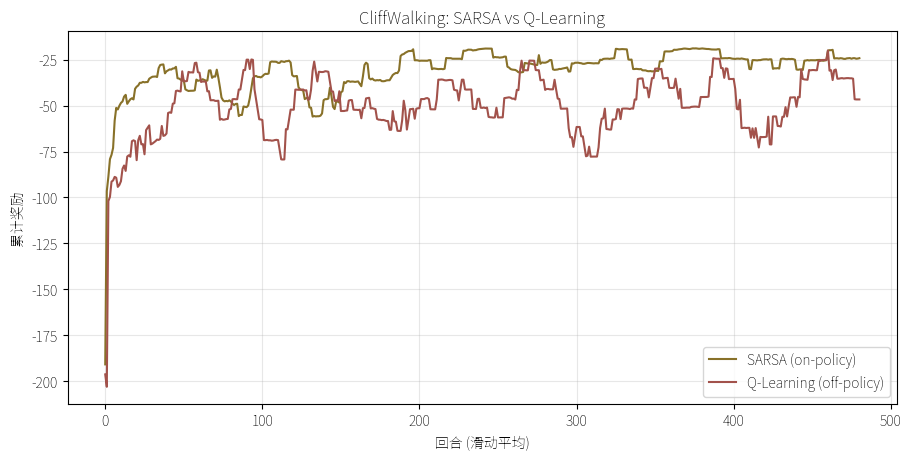

SARSA 末50回合平均: -23.8
Q-Learning 末50回合平均: -33.6


In [3]:
def moving_average(x, w=20):
    return np.convolve(x, np.ones(w)/w, mode='valid')

fig, ax = plt.subplots(figsize=(9, 4.5), constrained_layout=True)
ax.plot(moving_average(r_sarsa), color='#887129', label='SARSA (on-policy)')
ax.plot(moving_average(r_ql), color='#a2524b', label='Q-Learning (off-policy)')
ax.set_xlabel('回合 (滑动平均)'); ax.set_ylabel('累计奖励')
ax.set_title('CliffWalking: SARSA vs Q-Learning')
ax.legend(); ax.grid(alpha=0.3)
plt.show()

print(f'SARSA 末50回合平均: {np.mean(r_sarsa[-50:]):.1f}')
print(f'Q-Learning 末50回合平均: {np.mean(r_ql[-50:]):.1f}')

## 5.6 可视化学到的路径

并排展示 SARSA 和 Q-Learning 在 CliffWalking 上学到的贪婪路径。
SARSA 保守绕行，Q-Learning 贴边走最优。

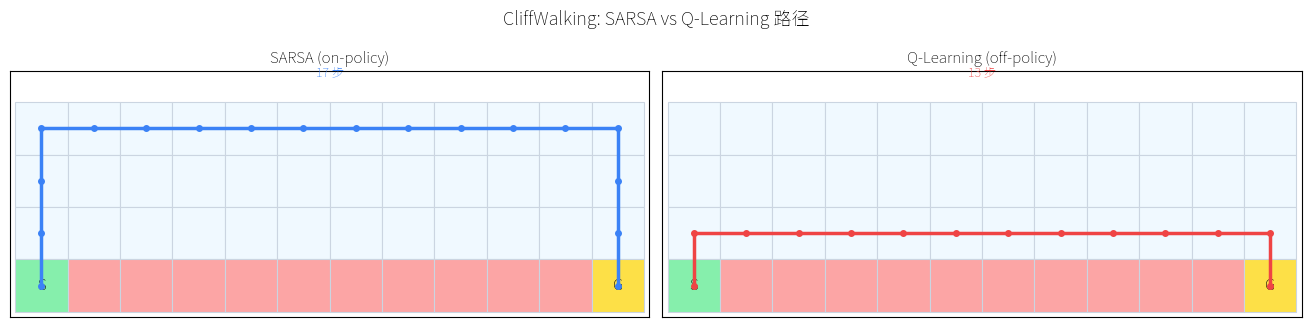

In [4]:
from viz_utils import visualize_cliffwalking
visualize_cliffwalking(Q_sarsa, Q_ql)

## 5.7 小结

- **on-policy (SARSA)**：学'我会怎么走'（考虑探索），训练稳定
- **off-policy (Q-Learning)**：学'最优怎么走'（不考虑探索），数据效率高

下一章：**DQN**——用神经网络做函数逼近，让 Q-Learning 能处理高维状态。